In [48]:
import graph_tool.collection 
import graph_tool.search 
import graph_tool as gt
import random
import numpy as np
import zstandard
import networkx as nx
import copy
import osmnx as ox

import random
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import subprocess
import ast


In [49]:
%load_ext autoreload
%autoreload 2

from src import utils as ut


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
place = 'Piedmont, California, USA'
g = ut.get_nx_from_ox(place)
wgt = 'length'

G = ox.graph_from_place(place, network_type='drive')

In [51]:
st_pairs = 100 #number of source, target pairs

In [52]:
st = ut.sample_st(g,st_pairs, seed = 116)

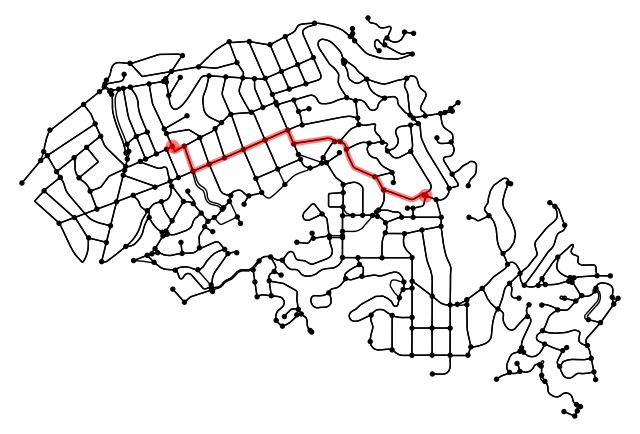

In [53]:
orig_node,dest_node = st[0][1],st[1][1]
route = nx.shortest_path(g, orig_node, dest_node, weight='length',method='dijkstra')
fig, ax = ox.plot_graph_route(G, route, bgcolor='white', edge_color='black', node_color='black')

In [54]:
folder_path = "/Users/antonioferrara/Desktop/GitHub/Maxmin-Fair-Paths/kspwlo-master/"
os.chdir(folder_path)
node_map = ut.save_graph_to_gr(g, 'tmp.gr', source=orig_node, target=dest_node,weight = wgt)
EKSP_node_map = ut.save_graph_to_gr_EKSP(g, 'tmp_EKSP.gr', source=orig_node, target=dest_node,weight = wgt)


In [55]:
ut.inverse_mapping([[1,2,3]],EKSP_node_map)


[[53017091, 53018397, 53018399]]

In [56]:
ut.inverse_mapping([[0,1,2]],node_map)


[[53017091, 53018397, 53018399]]

In [57]:
with open('tmpQ.txt', 'w') as file:
    file.write(f"{EKSP_node_map[orig_node]} {EKSP_node_map[dest_node]}\n")

In [58]:
import numpy as np
from contextlib import contextmanager
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm  # Import tqdm
import time  # Import time module

# Initialize lists to store the results and runtimes
results_FP_paths = []
results_random_FP_paths = []
results_yen_k_shortest_10 = []
#results_yen_k_shortest_100 = []
results_kspwlo_paths_08_10 = []
results_kspwlo_paths_08_100 = []
results_kspwlo_paths_05_10 = []
results_kspwlo_paths_05_100 = []
results_opplus_paths_08_10 = []
results_opplus_paths_05_10 = []
results_EKSP_paths_05_10 = []


lengths_FP_paths = []
lengths_random_FP_paths = []
lengths_yen_k_shortest_10 = []
#lengths_yen_k_shortest_100 = []
lengths_kspwlo_paths_08_10 = []
lengths_kspwlo_paths_08_100 = []
lengths_kspwlo_paths_05_10 = []
lengths_kspwlo_paths_05_100 = []
lengths_opplus_paths_08_10 = []
lengths_opplus_paths_05_10 = []
lengths_EKSP_paths_05_10 = []


runtimes_FP_paths = []
runtimes_random_FP_paths = []
runtimes_yen_k_shortest_10 = []
#runtimes_yen_k_shortest_100 = []
runtimes_kspwlo_paths_08_10 = []
runtimes_kspwlo_paths_08_100 = []
runtimes_kspwlo_paths_05_10 = []
runtimes_kspwlo_paths_05_100 = []
runtimes_opplus_paths_08_10 = []
runtimes_opplus_paths_05_10 = []
runtimes_EKSP_paths_05_10 = []


gini_FP_paths = []
gini_random_FP_paths = []
gini_yen_k_shortest_10 = []
#gini_yen_k_shortest_100 = []
gini_kspwlo_paths_08_10 = []
gini_kspwlo_paths_08_100 = []
gini_kspwlo_paths_05_10 = []
gini_kspwlo_paths_05_100 = []
gini_opplus_paths_08_10 = []
gini_opplus_paths_05_10 = []
gini_EKSP_paths_05_10 = []

# Iterate through pairs of nodes with a progress bar
for orig_node, dest_node in tqdm(zip(st[0], st[1]), total=len(st[0]), desc="Processing pairs of nodes"):
    
    print(orig_node, dest_node)
    # Measure time for the first block
    start_time = time.time()
    dag = ut.get_dag(g, orig_node, dest_node, weight=wgt)
    mid_time = time.time()
    elapsed_dag_time = mid_time - start_time
    
    start_time = time.time()
    K, alpha, model, result = ut.iterative_solver(dag, orig_node, dest_node) #LP solver, alpha are the satisf. probs
    final = ut.compute_probabilities_and_expectations(dag, result, dest_node) 
    dag = final['dag']
    end_time = time.time()
    
    #FP_paths = [i for i in nx.all_simple_paths(ut.remove_zero_prob_edges(dag), source=orig_node, target=dest_node)]
    
    elapsed_time_FP_paths = end_time - start_time + elapsed_dag_time
    runtimes_FP_paths.append(elapsed_time_FP_paths)
    #results_FP_paths.append(len(FP_paths))
    lengths_FP_paths.append(final['exp_length'])
    gini_FP_paths.append(ut.get_gini_from_alpha(alpha))   
    
    # Measure time for random_FP_paths
    start_time = time.time()
    random_FP_paths = ut.sample_k_random_FP(dag, orig_node, dest_node,  100)
    end_time = time.time()
    elapsed_time_random_FP = end_time - start_time + elapsed_dag_time
    
    runtimes_random_FP_paths.append(elapsed_time_random_FP)
    results_random_FP_paths.append(len(random_FP_paths))
    lengths_random_FP_paths.append(ut.average_path_length(random_FP_paths, g, wgt))
    ut.add_nodes_satisfaction(random_FP_paths, dag, 'random_fp')
    gini_random_FP_paths.append(ut.get_gini(dag, 'random_fp'))
    
    # Measure time for Yen's K-shortest paths k = 10
    start_time = time.time()
    yen_k_shortest_10 = ut.yen_k_paths(g, orig_node, dest_node, weight=wgt, k=10)
    end_time = time.time()
    elapsed_time_yen_10 = end_time - start_time
    runtimes_yen_k_shortest_10.append(elapsed_time_yen_10)
    results_yen_k_shortest_10.append(len(yen_k_shortest_10))
    lengths_yen_k_shortest_10.append(ut.average_path_length(yen_k_shortest_10, g, wgt))
    ut.add_nodes_satisfaction(yen_k_shortest_10, dag, 'yen_10')
    gini_yen_k_shortest_10.append(ut.get_gini(dag, 'yen_10'))
    
    
    # Measure time for Yen's K-shortest paths k = 100
    
    #start_time = time.time()
    #yen_k_shortest_100 = ut.yen_k_paths(g, orig_node, dest_node, weight=wgt, k=100)
    #end_time = time.time()
    #elapsed_time_yen_100 = end_time - start_time
    #runtimes_yen_k_shortest_100.append(elapsed_time_yen_100)
    #results_yen_k_shortest_100.append(len(yen_k_shortest_100))
    #lengths_yen_k_shortest_100.append(ut.average_path_length(yen_k_shortest_100, g, wgt))
    #ut.add_nodes_satisfaction(yen_k_shortest_100, dag, 'yen_100')
    #gini_yen_k_shortest_100.append(ut.get_gini(dag, 'yen_100'))
    
    

    # Measure time for KSPwlo 0.5 and k = 10
    start_time = time.time()
    kspwlo_paths_05_10 = ut.inverse_mapping(
        ut.execute_bash_command("tmp.gr", 10, 0.5, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
    end_time = time.time()
    elapsed_time_kspwlo_05_10 = end_time - start_time
    runtimes_kspwlo_paths_05_10.append(elapsed_time_kspwlo_05_10)
    results_kspwlo_paths_05_10.append(len(kspwlo_paths_05_10))
    lengths_kspwlo_paths_05_10.append(ut.average_path_length(kspwlo_paths_05_10, g, wgt))
    ut.add_nodes_satisfaction(kspwlo_paths_05_10, dag, 'kspwlo_paths_05_10')
    gini_kspwlo_paths_05_10.append(ut.get_gini(dag, 'kspwlo_paths_05_10'))

    
    # Measure time for KSPwlo 0.5 and k = 100
    start_time = time.time()
    kspwlo_paths_05_100 = ut.inverse_mapping(
        ut.execute_bash_command("tmp.gr", 100, 0.5, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
    end_time = time.time()
    elapsed_time_kspwlo_05_100 = end_time - start_time
    runtimes_kspwlo_paths_05_100.append(elapsed_time_kspwlo_05_100)
    results_kspwlo_paths_05_100.append(len(kspwlo_paths_05_100))
    lengths_kspwlo_paths_05_100.append(ut.average_path_length(kspwlo_paths_05_100, g, wgt))
    ut.add_nodes_satisfaction(kspwlo_paths_05_100, dag, 'kspwlo_paths_05_100')
    gini_kspwlo_paths_05_100.append(ut.get_gini(dag, 'kspwlo_paths_05_100'))
    
    
    # Measure time for KSPwlo 0.8 and k = 10
    start_time = time.time()
    node_map = ut.save_graph_to_gr(g, 'tmp.gr', source=orig_node, target=dest_node, weight=wgt)
    kspwlo_paths_08_10 = ut.inverse_mapping(
        ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
    end_time = time.time()
    elapsed_time_kspwlo_08_10 = end_time - start_time
    runtimes_kspwlo_paths_08_10.append(elapsed_time_kspwlo_08_10)
    results_kspwlo_paths_08_10.append(len(kspwlo_paths_08_10))
    lengths_kspwlo_paths_08_10.append(ut.average_path_length(kspwlo_paths_08_10, g, wgt))
    ut.add_nodes_satisfaction(kspwlo_paths_08_10, dag, 'kspwlo_paths_08_10')
    gini_kspwlo_paths_08_10.append(ut.get_gini(dag, 'kspwlo_paths_08_10'))

    
    # Measure time for KSPwlo 0.8 and k = 100
    start_time = time.time()
    kspwlo_paths_08_100 = ut.inverse_mapping(
        ut.execute_bash_command("tmp.gr", 100, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
    end_time = time.time()
    elapsed_time_kspwlo_08_100 = end_time - start_time
    runtimes_kspwlo_paths_08_100.append(elapsed_time_kspwlo_08_100)
    results_kspwlo_paths_08_100.append(len(kspwlo_paths_08_100))
    lengths_kspwlo_paths_08_100.append(ut.average_path_length(kspwlo_paths_08_100, g, wgt))
    ut.add_nodes_satisfaction(kspwlo_paths_08_100, dag, 'kspwlo_paths_08_100')
    gini_kspwlo_paths_08_100.append(ut.get_gini(dag, 'kspwlo_paths_08_100'))
    
    
    # Measure time for Opplus 0.5 and k = 10
    start_time = time.time()
    opplus_paths_05_10 = ut.inverse_mapping(
        ut.execute_bash_command("tmp.gr", 10, 0.5, node_map[orig_node], node_map[dest_node], "opplus"), node_map)
    end_time = time.time()
    elapsed_time_opplus_05_10 = end_time - start_time
    runtimes_opplus_paths_05_10.append(elapsed_time_opplus_05_10)
    results_opplus_paths_05_10.append(len(opplus_paths_05_10))
    lengths_opplus_paths_05_10.append(ut.average_path_length(opplus_paths_05_10, g, wgt))
    ut.add_nodes_satisfaction(opplus_paths_05_10, dag, 'opplus_paths_05_10')
    gini_opplus_paths_05_10.append(ut.get_gini(dag, 'opplus_paths_05_10'))
    
    
    # Measure time for Opplus 0.8 and k = 10
    start_time = time.time()
    node_map = ut.save_graph_to_gr(g, 'tmp.gr', source=orig_node, target=dest_node, weight=wgt)
    opplus_paths_08_10 = ut.inverse_mapping(
        ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "opplus"), node_map)
    end_time = time.time()
    elapsed_time_opplus_08_10 = end_time - start_time
    runtimes_opplus_paths_08_10.append(elapsed_time_opplus_08_10)
    results_opplus_paths_08_10.append(len(opplus_paths_08_10))
    lengths_opplus_paths_08_10.append(ut.average_path_length(opplus_paths_08_10, g, wgt))
    ut.add_nodes_satisfaction(opplus_paths_08_10, dag, 'opplus_paths_08_10')
    gini_opplus_paths_08_10.append(ut.get_gini(dag, 'opplus_paths_08_10'))
    
    with open('tmpQ.txt', 'w') as file:
        file.write(f"{EKSP_node_map[orig_node]} {EKSP_node_map[dest_node]}\n")
    
    #print(EKSP_node_map[orig_node],EKSP_node_map[dest_node])
    #print(ut.execute_EKSP("tmp_EKSP.gr", 10, 0.9))
    #print('qui')
    
    start_time = time.time()
    EKSP_paths_05_10 = ut.inverse_mapping(ut.execute_EKSP("tmp_EKSP.gr", 10, 0.8), node_map)#it is with node_map results shifted by 1
    #print(EKSP_paths_05_10)
    end_time = time.time()
    elapsed_time_EKSP_05_10 = end_time - start_time
    runtimes_EKSP_paths_05_10.append(elapsed_time_EKSP_05_10)
    results_EKSP_paths_05_10.append(len(EKSP_paths_05_10))
    lengths_EKSP_paths_05_10.append(ut.average_path_length(EKSP_paths_05_10, g, wgt))
    ut.add_nodes_satisfaction(EKSP_paths_05_10, dag, 'EKSP_paths_05_10')
    gini_EKSP_paths_05_10.append(ut.get_gini(dag, 'EKSP_paths_05_10'))



Processing pairs of nodes:   1%|        | 1/100 [00:00<00:17,  5.61it/s]

256338812 53092201
53118374 53114734


Processing pairs of nodes:   2%|▏       | 2/100 [00:00<00:25,  3.91it/s]

53146451 53116276


Processing pairs of nodes:   3%|▏       | 3/100 [00:01<00:43,  2.21it/s]

...

Processing pairs of nodes:  97%|██████▊| 97/100 [00:34<00:01,  2.00it/s]

53050875 53040495


Processing pairs of nodes:  99%|██████▉| 99/100 [00:34<00:00,  2.89it/s]

53079888 305541919
53091598 53113946


Processing pairs of nodes: 100%|██████| 100/100 [00:35<00:00,  2.85it/s]


In [59]:
# Calculate mean and standard deviation for each method

# Function to calculate mean and standard deviation for runtimes
def calculate_runtime_mean_std(runtimes):
    runtime_mean = np.mean(runtimes)
    runtime_std = np.std(runtimes)
    return runtime_mean, runtime_std

# Function to calculate mean and standard deviation for results
def calculate_result_mean_std(results):
    result_mean = np.mean(results)
    result_std = np.std(results)
    return result_mean, result_std

# Function to calculate mean for path lengths
def calculate_length_mean(lengths):
    return np.mean(lengths)

methods = ["FP_paths", "random_FP_paths", 
           "yen_k_shortest_10", "esx-c_paths_05_10", "esx-c_paths_08_10", 
           "opplus_paths_05_10", "opplus_paths_08_10",
           #"yen_k_shortest_100",
           "esx-c_paths_05_100", "esx-c_paths_08_100",
           "EKSP_08_10"
           ]

results_lists = [results_FP_paths, results_random_FP_paths,
                 results_yen_k_shortest_10, results_kspwlo_paths_05_10, results_kspwlo_paths_08_10,
                 results_opplus_paths_05_10, results_opplus_paths_08_10,
                 #results_yen_k_shortest_100,
                 results_kspwlo_paths_05_100, results_kspwlo_paths_08_100,results_EKSP_paths_05_10]

runtimes_lists = [runtimes_FP_paths, runtimes_random_FP_paths,
                  runtimes_yen_k_shortest_10, runtimes_kspwlo_paths_05_10, runtimes_kspwlo_paths_08_10,
                  runtimes_opplus_paths_05_10, runtimes_opplus_paths_08_10,
                  #runtimes_yen_k_shortest_100,
                  runtimes_kspwlo_paths_05_100, runtimes_kspwlo_paths_08_100, runtimes_EKSP_paths_05_10]

lengths_lists = [lengths_FP_paths, lengths_random_FP_paths,
                 lengths_yen_k_shortest_10, lengths_kspwlo_paths_05_10, lengths_kspwlo_paths_08_10,
                 lengths_opplus_paths_05_10, lengths_opplus_paths_08_10,
                 #lengths_yen_k_shortest_100,
                 lengths_kspwlo_paths_05_100, lengths_kspwlo_paths_08_100, lengths_EKSP_paths_05_10]

gini_lists = [gini_FP_paths, gini_random_FP_paths,
                 gini_yen_k_shortest_10, gini_kspwlo_paths_05_10, gini_kspwlo_paths_08_10,
                 gini_opplus_paths_05_10, gini_opplus_paths_08_10,
                 #gini_yen_k_shortest_100,
                 gini_kspwlo_paths_05_100, gini_kspwlo_paths_08_100, gini_EKSP_paths_05_10]



data = []

for method, results, runtimes, lengths, gini in zip(methods, results_lists, runtimes_lists, lengths_lists,gini_lists):
    result_mean, result_std = calculate_result_mean_std(results)
    runtime_mean, runtime_std = calculate_runtime_mean_std(runtimes)
    length_mean, length_std = np.mean(lengths), np.std(lengths)
    gini_mean,gini_std = np.nanmean(gini), np.nanstd(gini)
    data.append([method, 
                 result_mean,
                 length_mean, length_std,
                 runtime_mean, runtime_std,
                 gini_mean,gini_std])
    
df = pd.DataFrame(data, columns=["Method",  "Number of paths",  
                                 "Length", "Std Length",
                                 "Runtime", "Std Runtime",
                                "Gini", "Gini Std"])

# Print the DataFrame
print(df)

file_path = f'../FairShortPath/results/{place}_new.csv'

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

               Method  Number of paths       Length   Std Length   Runtime  \
0            FP_paths              NaN  2035.529175  1003.795039  0.089684   
1     random_FP_paths           100.00  2002.044092   980.238558  0.022110   
2   yen_k_shortest_10            10.00  1957.753137   854.946860  0.034737   
3   esx-c_paths_05_10            10.00  4395.401190  1738.761859  0.020343   
4   esx-c_paths_08_10            10.00  3447.111610  1195.329170  0.016439   
5  opplus_paths_05_10             8.90  2523.224143   894.571911  0.023225   
6  opplus_paths_08_10             9.76  2124.951798   835.032739  0.014294   
7  esx-c_paths_05_100           100.00  3315.167182  1353.753542  0.045701   
8  esx-c_paths_08_100           100.00  4264.191376  1843.290971  0.078045   
9          EKSP_08_10            10.00  2065.751464   850.303800  0.016346   

   Std Runtime      Gini  Gini Std  
0     0.090103  0.196542  0.110800  
1     0.001534  0.271429  0.152353  
2     0.031557  0.344508  0.17

/Users/antonioferrara/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/antonioferrara/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/antonioferrara/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/antonioferrara/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/antonioferrara/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [60]:
file_path = f'../FairShortPath/results/{place}_new.csv'
import pandas as pd
pd.read_csv(file_path)

,Method,Number of paths,Length,Std Length,Runtime,Std Runtime,Gini,Gini Std
0,FP_paths,NaN,2035.529175,1003.795039,0.089684,0.090103,0.196542,0.110800
1,random_FP_paths,100.00,2002.044092,980.238558,0.022110,0.001534,0.271429,0.152353
2,yen_k_shortest_10,10.00,1957.753137,854.946860,0.034737,0.031557,0.344508,0.172318
3,esx-c_paths_05_10,10.00,4395.401190,1738.761859,0.020343,0.004201,0.380270,0.089460
4,esx-c_paths_08_10,10.00,3447.111610,1195.329170,0.016439,0.008395,0.412976,0.088155
5,opplus_paths_05_10,8.90,2523.224143,894.571911,0.023225,0.045572,0.331645,0.085986
6,opplus_paths_08_10,9.76,2124.951798,835.032739,0.014294,0.001859,0.340490,0.126239
7,esx-c_paths_05_100,100.00,3315.167182,1353.753542,0.045701,0.018403,0.296470,0.108786
8,esx-c_paths_08_100,100.00,4264.191376,1843.290971,0.078045,0.037258,0.301517,0.102405
9,EKSP_08_10,10.00,2065.751464,850.303800,0.016346,0.009571,0.326143,0.138876


In [61]:
%time
sp_length,sp_nodes = ut.list_shortest_path_nx(g, wgt, st[0], st[1])
lfp_length,lfp_nodes,dag_nodes = ut.list_longest_forward_path(g, wgt, st[0], st[1])
    

CPU times: user 1 µs, sys: 0 ns, total: 1 µs
Wall time: 4.77 µs
unreachable targets: 0


In [62]:
np.mean(sp_length),np.mean(lfp_length)

(1860.06996, 2060.58421)

In [63]:
#df.to_csv(file_path, index=False)

In [64]:
gini_EKSP_paths_05_10

[0.15117466802860058,
 0.4888941398865785,
 0.19620901639344268,
 0.29755944931163947,
 0.5053402881271734,
 0.5372335199921405,
 0.39743589743589747,
 0.43057198458427126,
 0.31562500000000004,
 0.17739403453689184,
 0.26171529619805467,
 0.16382416526543353,
 0.2061688311688311,
 0.2804210526315789,
 0.418419822346891,
 0.1803847014090808,
 0.24715768660405335,
 0.20037453183520582,
 0.22849298352654057,
 0.153225806451613,
 0.46362139917695466,
 0.51953125,
 0.301994301994302,
 0.40463029720419774,
 0.29521998913633885,
 0.16509433962264153,
 0.4514034561981819,
 0.2705971277399849,
 0.6905300886625165,
 0.28097345132743357,
 0.4745011086474501,
 0.17579408543263964,
 0.5421727395411606,
 0.37109646079111736,
 0.23910550458715596,
 0.16666666666666663,
 0.18452380952380953,
 0.3571903811424769,
 0.22619047619047628,
 0.21830295904369967,
 0.7137686739565685,
 0.6784736955385419,
 0.29585798816568054,
 0.5419479267116682,
 0.3272222222222223,
 0.46362139917695466,
 0.4312463296743007